<a href="https://colab.research.google.com/github/Junaid-Altaf/Ai-object-narrator/blob/main/Cross_Domain_Prompt_Optimization_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this first in Colab
!pip install transformers
!pip install datasets
!pip install peft
!pip install torch
!pip install pandas
!pip install matplotlib

In [ ]:
# Test flan-t5-base loads correctly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
from datasets import load_dataset

print("Loading Medical Dataset...")
try:
    medical_data = load_dataset(
        "medmcqa",
        trust_remote_code=True
    )
    print("✅ Medical Data Loaded!")
    print(medical_data)
except Exception as e:
    print(f"Error: {e}")
    medical_data = load_dataset(
        "qiaojin/PubMedQA",
        "pqa_labeled",
        trust_remote_code=True
    )

print("\nLoading Financial Dataset...")
try:
    financial_data = load_dataset(
        "financial_phrasebank",
        "sentences_allagree",
        trust_remote_code=True
    )
    print("✅ Financial Data Loaded!")
    print(financial_data)
except Exception as e:
    print(f"Error: {e}")
    financial_data = load_dataset(
        "zeroshot/twitter-financial-news-sentiment"
    )

# Preview both datasets
print("\n=== Medical Sample ===")
print(medical_data["train"][0])

print("\n=== Financial Sample ===")
print(financial_data["train"][0])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'medmcqa' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Medical Dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

...

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]


=== Medical Sample ===
{'id': 'e9ad821a-c438-4965-9f77-760819dfa155', 'question': 'Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma', 'opa': 'Hyperplasia', 'opb': 'Hyperophy', 'opc': 'Atrophy', 'opd': 'Dyplasia', 'cop': 2, 'choice_type': 'single', 'exp': 'Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnancy, tumors, uterine prolapse or functional disorders cause hydronephrosis which by definition is used to describe dilatation of renal pelvis and calculus associated with progressive atrophy of the kidney due to obstruction to the outflow of urine Refer Robbins 7yh/9,1012,9/e. P950', 'subject_name': 'Anatomy', 'topic_name': 'Urinary tract'}

=== Financial Sample ===
{'text': '$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', 'label': 0}


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Financial Prompt
financial_prompt = "Classify sentiment of financial text: Revenue increased significantly this quarter"
fin_input = tokenizer(financial_prompt, return_tensors="pt")
fin_output = model.generate(**fin_input, max_new_tokens=50)
fin_result = tokenizer.decode(fin_output[0], skip_special_tokens=True)
print("Financial Result:", fin_result)

# Medical Prompt
medical_prompt = "Extract key information: Patient shows high fever and respiratory issues"
med_input = tokenizer(medical_prompt, return_tensors="pt")
med_output = model.generate(**med_input, max_new_tokens=50)
med_result = tokenizer.decode(med_output[0], skip_special_tokens=True)
print("Medical Result:", med_result)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Financial Result: positive
Medical Result: A patient with a high fever and respiratory issues.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    output_attentions=True
)

def extract_lookback_attention(prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            output_attentions=True,
            return_dict_in_generate=True
        )

    # Extract cross attention weights
    cross_attentions = outputs.cross_attentions
    print(f"Attention Layers: {len(cross_attentions)}")
    print(f"Attention Shape: {cross_attentions[0][0].shape}")
    return cross_attentions

# Test on financial domain
print("=== Financial Domain ===")
fin_attention = extract_lookback_attention(
    "Classify financial sentiment: Stock market crashed today"
)

# Test on medical domain
print("\n=== Medical Domain ===")
med_attention = extract_lookback_attention(
    "Extract medical info: Patient diagnosed with pneumonia"
)

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


=== Financial Domain ===
Attention Layers: 2
Attention Shape: torch.Size([1, 12, 1, 10])

=== Medical Domain ===
Attention Layers: 6
Attention Shape: torch.Size([1, 12, 1, 9])


In [ ]:
import torch
import numpy as np

def concentration_score(attention_weights):
    """
    Measures how concentrated attention is
    on prompt tokens
    Higher score = Better concentration = Less dilution
    """
    # Average across attention heads
    avg_attention = attention_weights.mean(dim=1)

    # Calculate concentration
    concentration = avg_attention.max(dim=-1).values.mean()

    # Calculate entropy for dilution measurement
    entropy = -(avg_attention *
                torch.log(avg_attention + 1e-9)).sum(dim=-1).mean()

    return {
        "concentration": concentration.item(),
        "entropy": entropy.item()
    }

# Compare domains
fin_score = concentration_score(fin_attention[0][0])
med_score = concentration_score(med_attention[0][0])

print("\n=== Concentration Results ===")
print(f"Financial - Concentration: {fin_score['concentration']:.4f}")
print(f"Financial - Entropy:       {fin_score['entropy']:.4f}")
print(f"Medical   - Concentration: {med_score['concentration']:.4f}")
print(f"Medical   - Entropy:       {med_score['entropy']:.4f}")


=== Concentration Results ===
Financial - Concentration: 0.7242
Financial - Entropy:       1.1289
Medical   - Concentration: 0.8042
Medical   - Entropy:       0.7937


      Domain  Concentration   Entropy
0  Financial       0.724171  1.128852
1    Medical       0.804165  0.793686


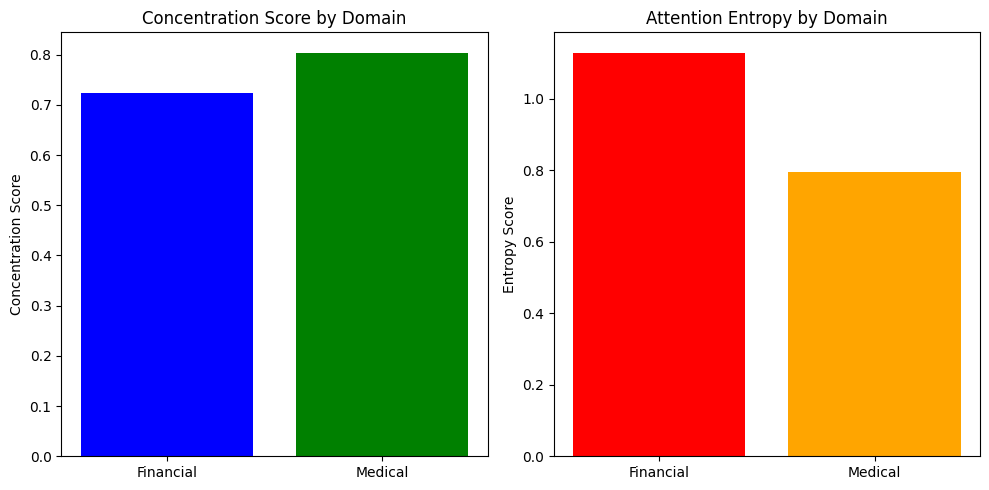

Results saved!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Save results
results = {
    "Domain": ["Financial", "Medical"],
    "Concentration": [
        fin_score["concentration"],
        med_score["concentration"]
    ],
    "Entropy": [
        fin_score["entropy"],
        med_score["entropy"]
    ]
}

df = pd.DataFrame(results)
print(df)
df.to_csv("results.csv", index=False)

# Plot results
plt.figure(figsize=(10, 5))

# Concentration plot
plt.subplot(1, 2, 1)
plt.bar(results["Domain"],
        results["Concentration"],
        color=["blue", "green"])
plt.title("Concentration Score by Domain")
plt.ylabel("Concentration Score")

# Entropy plot
plt.subplot(1, 2, 2)
plt.bar(results["Domain"],
        results["Entropy"],
        color=["red", "orange"])
plt.title("Attention Entropy by Domain")
plt.ylabel("Entropy Score")

plt.tight_layout()
plt.savefig("attention_results.png")
plt.show()
print("Results saved!")